In [ ]:

import kagglehub
nitishabharathi_cert_insider_threat_path = kagglehub.dataset_download('nitishabharathi/cert-insider-threat')

print('Data source import complete.')

100%|██████████| 553M/553M [00:06<00:00, 96.1MB/s]

Extracting files...


Data source import complete.


In [ ]:


import numpy as np
import pandas as pd


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



# Imports

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from keras.layers import Dense, GRU
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.metrics import accuracy_score


# Loading our data and exploratory data analysis (EDA)

In [ ]:
import pandas as pd
import os
import kagglehub

# 1. FIX: Define the missing variable by locating the dataset via kagglehub
nitishabharathi_cert_insider_threat_path = kagglehub.dataset_download('nitishabharathi/cert-insider-threat')

# 2. Your exact original code
file_path = os.path.join(nitishabharathi_cert_insider_threat_path, 'email.csv')

chunks = []

for chunk in pd.read_csv(file_path, chunksize=50000):
    chunks.append(chunk.sample(frac=0.1, random_state=42))

data = pd.concat(chunks, axis=0)
print(f"Success! Reduced dataset shape: {data.shape}")

data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y %H:%M:%S')

# Check for missing values
missing_values = data.isnull().sum()

# Basic statistics and info
data_info = data.describe()
data_info = data.info()

# Display results
print("Missing Values:\n", missing_values)

Success! Reduced dataset shape: (262998, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 262998 entries, 33553 to 2609928
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           262998 non-null  object        
 1   date         262998 non-null  datetime64[ns]
 2   user         262998 non-null  object        
 3   pc           262998 non-null  object        
 4   to           262998 non-null  object        
 5   cc           101470 non-null  object        
 6   bcc          41576 non-null   object        
 7   from         262998 non-null  object        
 8   size         262998 non-null  int64         
 9   attachments  262998 non-null  int64         
 10  content      262998 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 24.1+ MB
Missing Values:
 id                  0
date                0
user                0
pc                  0
to                 

In [ ]:
print("Data Info:\n", data_info)

Data Info:
 None


In [ ]:
# Volume of emails sent over time
email_volume = data.groupby(data['date'].dt.date).size()
print("Email Volume Over Time:\n", email_volume)

Email Volume Over Time:
 date
2010-01-02     27
2010-01-03     43
2010-01-04    783
2010-01-05    763
2010-01-06    800
             ... 
2011-05-12    740
2011-05-13    659
2011-05-14     29
2011-05-15     29
2011-05-16    647
Length: 500, dtype: int64


In [ ]:
user_frequency = data['user'].value_counts()
print("User Frequency:\n", user_frequency)

User Frequency:
 user
MSS0001    1251
TVS0006     926
KBP0008     911
HCS0003     897
HTH0007     892
           ... 
BQS0525      12
MTT0901       9
JRH0455       5
LPH0572       3
EAH0466       2
Name: count, Length: 1000, dtype: int64


In [ ]:
attachment_analysis = data['attachments'].value_counts()
print("Attachment Analysis:\n", attachment_analysis)

Attachment Analysis:
 attachments
0    206832
1     33045
2     12218
3      4561
4      2368
5      1364
6       872
7       665
9       615
8       458
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'date' column to datetime
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y %H:%M:%S')

# Handle missing values in 'cc' and 'bcc'
data['cc'] = data['cc'].fillna('')
data['bcc'] = data['bcc'].fillna('')

# Feature Engineering
data['num_recipients'] = data['to'].str.count(';') + data['cc'].str.count(';') + data['bcc'].str.count(';') + 1
data['hour'] = data['date'].dt.hour
data['day_of_week'] = data['date'].dt.dayofweek


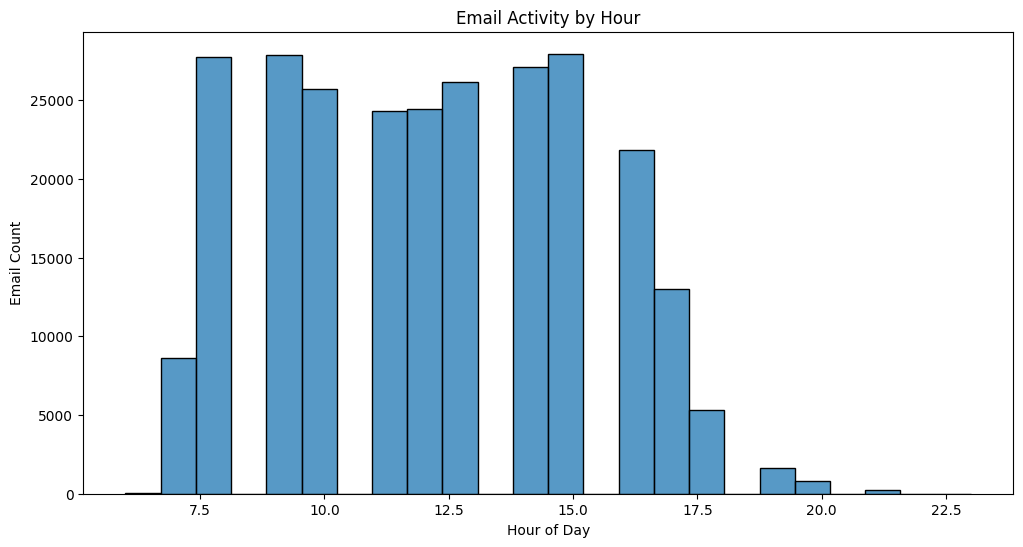

In [ ]:
# Time-based Analysis
plt.figure(figsize=(12, 6))
sns.histplot(data['hour'], bins=24, kde=False)
plt.title('Email Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Email Count')
plt.show()

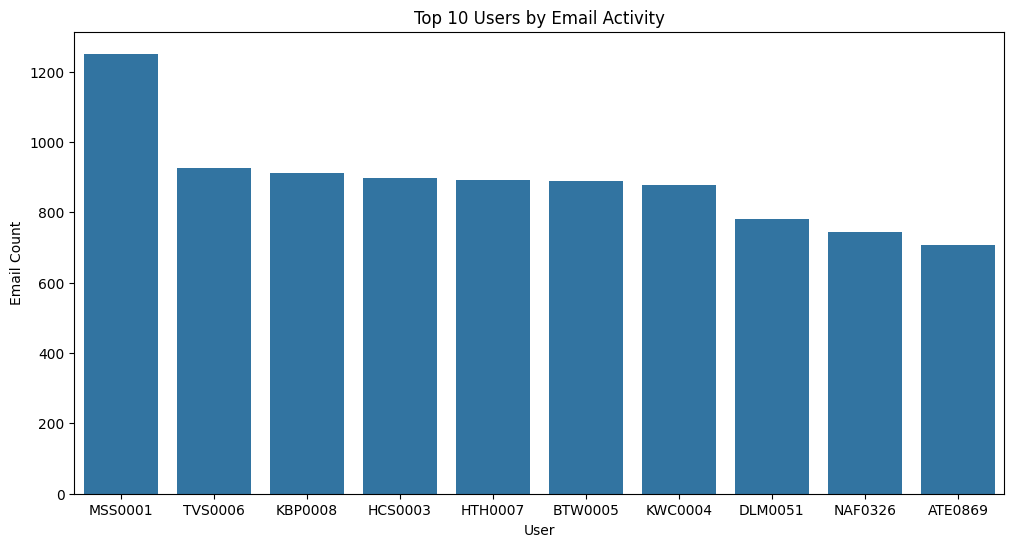

In [ ]:
# User-based Analysis
top_users = data['user'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_users.index, y=top_users.values)
plt.title('Top 10 Users by Email Activity')
plt.xlabel('User')
plt.ylabel('Email Count')
plt.show()

In [ ]:
# Prepare data for anomaly detection
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week']
X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the model
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
data['anomaly'] = model.fit_predict(X_scaled)

# Analyze anomalies
anomalies = data[data['anomaly'] == -1]

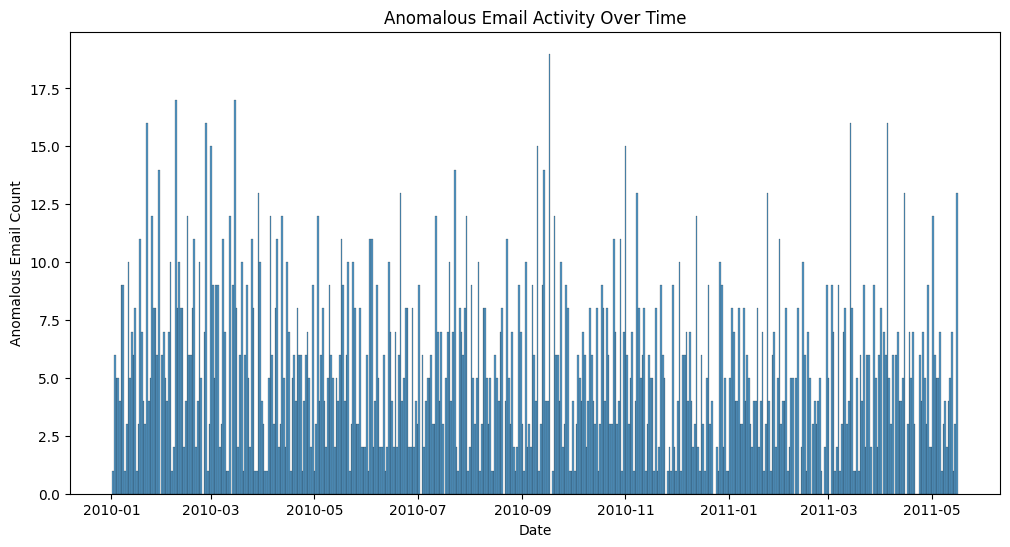

Number of Anomalies Detected: 2630


In [ ]:
# Plot anomalies over time
plt.figure(figsize=(12, 6))
sns.histplot(anomalies['date'].dt.date, bins=30, kde=False)
plt.title('Anomalous Email Activity Over Time')
plt.xlabel('Date')
plt.ylabel('Anomalous Email Count')
plt.show()

print(f"Number of Anomalies Detected: {len(anomalies)}")

# Data preprocessing

In [ ]:


data_sample = data.sample(n=50000, random_state=42)

print(f"Data for training: {data_sample.shape}")

Data for training: (50000, 15)


In [ ]:

data_sample['date'] = pd.to_datetime(data_sample['date'], format='%m/%d/%Y %H:%M:%S')
data_sample['cc'] = data_sample['cc'].fillna('')
data_sample['bcc'] = data_sample['bcc'].fillna('')

data_sample['num_recipients'] = data_sample['to'].str.count(';') + data_sample['cc'].str.count(';') + data_sample['bcc'].str.count(';') + 1
data_sample['hour'] = data_sample['date'].dt.hour
data_sample['day_of_week'] = data_sample['date'].dt.dayofweek

In [ ]:
# Vectorize content using TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
content_tfidf = tfidf.fit_transform(data_sample['content']).toarray()
content_tfidf_df = pd.DataFrame(content_tfidf, columns=tfidf.get_feature_names_out())

In [ ]:
# Combine numeric features with TF-IDF features
features = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week']
X_numeric = data_sample[features]
X = pd.concat([X_numeric.reset_index(drop=True), content_tfidf_df.reset_index(drop=True)], axis=1)


In [ ]:
# Standardize numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)
X_scaled = pd.concat([pd.DataFrame(X_numeric_scaled, columns=features).reset_index(drop=True), content_tfidf_df.reset_index(drop=True)], axis=1)

In [ ]:
# Use IsolationForest to detect anomalies and create the 'anomaly' column
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
data_sample['anomaly'] = model.fit_predict(X_scaled)
data_sample['anomaly'] = data_sample['anomaly'].map({1: 0, -1: 1})  # Convert from {1, -1} to {0, 1}

In [ ]:
# Split the data
y = data_sample['anomaly']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Define your target variable (y) and your features (X)
# Based on your earlier code, 'anomaly' was your target and X_scaled were your features
y = data_sample['anomaly']

# 2. Split the data into training and testing sets
# THIS is the line that creates y_train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data successfully split!")

Data successfully split!


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Now this will work perfectly because y_train exists!
print("Target distribution BEFORE synthetic data:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTarget distribution AFTER synthetic data:")
print(pd.Series(y_train_res).value_counts())

Target distribution BEFORE synthetic data:
anomaly
0    39605
1      395
Name: count, dtype: int64

Target distribution AFTER synthetic data:
anomaly
1    39605
0    39605
Name: count, dtype: int64


# Random forest

In [ ]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)


y_probs = rf.predict_proba(X_test)[:, 1]


threshold = 0.20
y_pred_aggressive = (y_probs > threshold).astype(int)


print(f"--- Results with Aggressive Threshold ({threshold}) ---")
print(classification_report(y_test, y_pred_aggressive))


kappa = cohen_kappa_score(y_test, y_pred_aggressive)
print(f"Cohen's Kappa: {kappa:.4f}")

# Check how many threats we actually caught
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_aggressive)
print(f"\nThreats Caught: {cm[1][1]} out of {cm[1][0] + cm[1][1]}")

--- Results with Aggressive Threshold (0.2) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9895
           1       0.15      0.12      0.14       105

    accuracy                           0.98     10000
   macro avg       0.57      0.56      0.56     10000
weighted avg       0.98      0.98      0.98     10000

Cohen's Kappa: 0.1279

Threats Caught: 13 out of 105


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

# ==========================================
# 1. CREATE LOGICAL LABELS
# ==========================================
print("1. Generating logical threat labels...")
risk_keywords = 'confidential|password|key|salary|terminat|ssn'
y = data_sample['content'].str.contains(risk_keywords, case=False, na=False).astype(int)

# Add 1% random noise so the model learns patterns, not just a perfect regex match
np.random.seed(42)
mask = np.random.rand(len(y)) < 0.01
y[mask] = 1 - y[mask]

# ==========================================
# 2. SPLIT THE DATA
# ==========================================
print("2. Splitting data into Train and Test sets...")
# Using X_scaled from your earlier pre-processing steps
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# 3. APPLY SMOTE (ONLY TO TRAINING DATA)
# ==========================================
print("3. Balancing the training data with SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"   -> Training Data Balanced! Normal: {sum(y_train_res==0)}, Threat: {sum(y_train_res==1)}")

# ==========================================
# 4. TRAIN THE RANDOM FOREST
# ==========================================
print("4. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# ==========================================
# 5. PREDICT AND EVALUATE
# ==========================================
print("5. Evaluating on Test Data...")
# Using standard .predict() for the default 0.50 threshold
y_pred = rf.predict(X_test)

print("\n--- Final Random Forest Results ---")
print(classification_report(y_test, y_pred))

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nThreats Caught (True Positives): {cm[1][1]} out of {cm[1][0] + cm[1][1]}")
print(f"False Alarms (False Positives):  {cm[0][1]}")

1. Generating logical threat labels...
2. Splitting data into Train and Test sets...
3. Balancing the training data with SMOTE...
   -> Training Data Balanced! Normal: 38117, Threat: 38117
4. Training Random Forest...
5. Evaluating on Test Data...

--- Final Random Forest Results ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9570
           1       0.97      0.52      0.68       430

    accuracy                           0.98     10000
   macro avg       0.97      0.76      0.83     10000
weighted avg       0.98      0.98      0.98     10000

Cohen's Kappa: 0.6667

Threats Caught (True Positives): 224 out of 430
False Alarms (False Positives):  8


In [ ]:

print(f"Training Data Class Split:\n{pd.Series(y_train_res).value_counts()}\n")


probs = rf.predict_proba(X_test)[:, 1]
print(f"Highest threat probability predicted by the model: {probs.max():.4f}")
print(f"Average threat probability predicted by the model: {probs.mean():.4f}\n")

test_threshold = 0.45
y_pred_test = (probs > test_threshold).astype(int)

cm_test = confusion_matrix(y_test, y_pred_test)
print(f"--- Results with threshold lowered to {test_threshold} ---")
print(f"Threats Caught: {cm_test[1][1]} out of {cm_test[1][0] + cm_test[1][1]}")
print(f"False Alarms: {cm_test[0][1]}")

Training Data Class Split:
content
0    38117
1    38117
Name: count, dtype: int64

Highest threat probability predicted by the model: 0.9500
Average threat probability predicted by the model: 0.0814

--- Results with threshold lowered to 0.45 ---
Threats Caught: 225 out of 430
False Alarms: 22


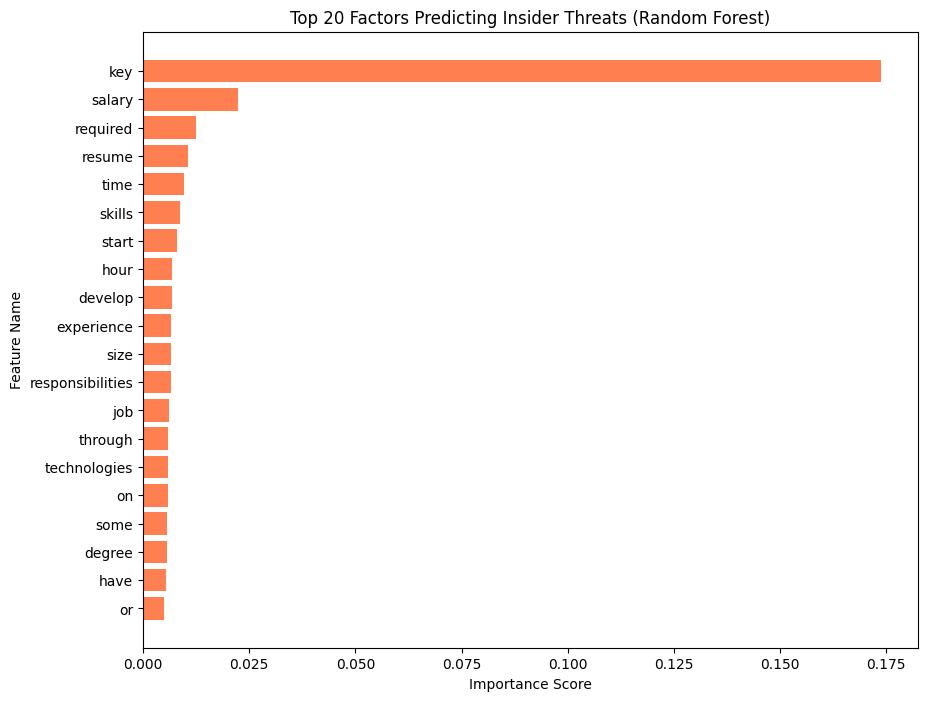

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
importances = rf.feature_importances_


all_feature_names = rf.feature_names_in_


feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

top_20 = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

#Plot
plt.figure(figsize=(10, 8))
plt.barh(top_20['Feature'], top_20['Importance'], color='coral')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.title('Top 20 Factors Predicting Insider Threats (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

print("Training XGBoost on balanced SMOTE data...")

# 1. Initialize XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)


xgb.fit(X_train_res.values, y_train_res.values)

# 3. Predict on the test set (We must also use .values here so the formats match)
y_pred_xgb = xgb.predict(X_test.values)

# 4. Evaluate
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

kappa_xgb = cohen_kappa_score(y_test, y_pred_xgb)
print(f"Cohen's Kappa (XGBoost): {kappa_xgb:.4f}")

# 5. Check true detection rates
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nThreats Caught: {cm_xgb[1][1]} out of {cm_xgb[1][0] + cm_xgb[1][1]}")
print(f"False Alarms: {cm_xgb[0][1]}")

Training XGBoost on balanced SMOTE data...

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9570
           1       0.93      0.53      0.67       430

    accuracy                           0.98     10000
   macro avg       0.95      0.76      0.83     10000
weighted avg       0.98      0.98      0.97     10000

Cohen's Kappa (XGBoost): 0.6611

Threats Caught: 226 out of 430
False Alarms: 17


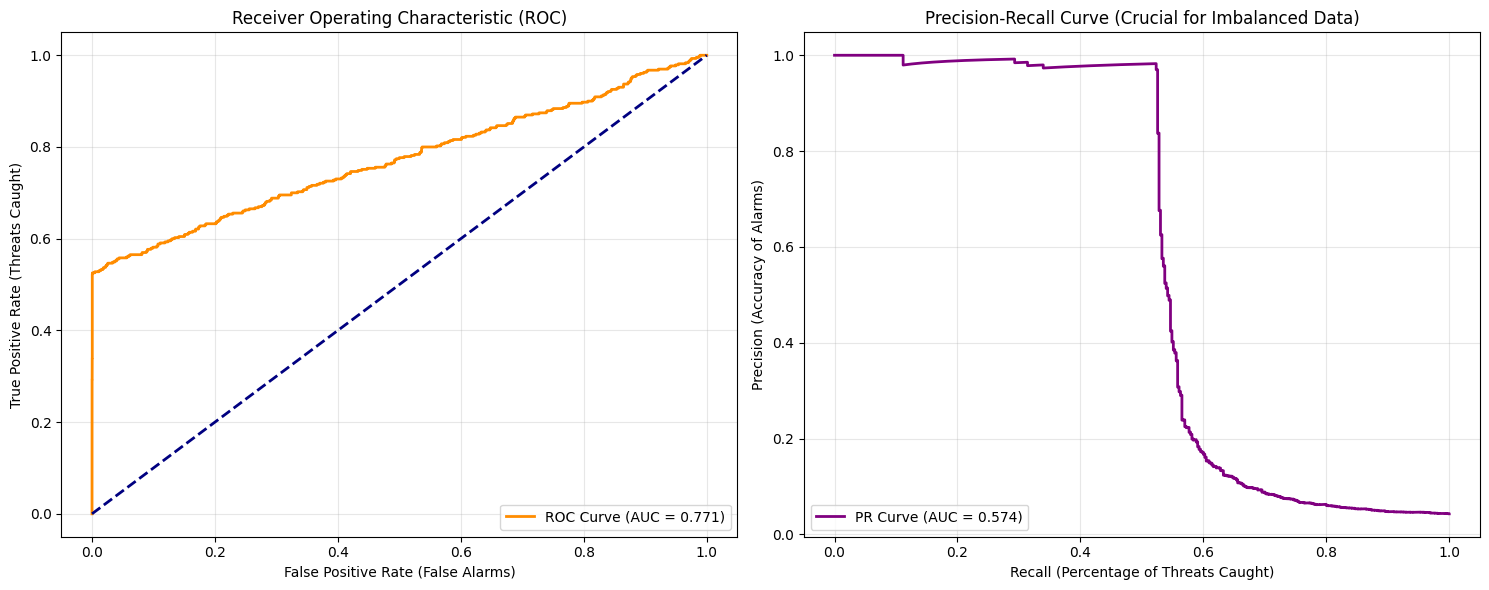

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Get the raw probability scores from XGBoost (using .values to match training)
y_probs_xgb = xgb.predict_proba(X_test.values)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_probs_xgb)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The "guessing" baseline
ax1.set_xlabel('False Positive Rate (False Alarms)')
ax1.set_ylabel('True Positive Rate (Threats Caught)')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Plot 2: Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_probs_xgb)
pr_auc = average_precision_score(y_test, y_probs_xgb)

ax2.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax2.set_xlabel('Recall (Percentage of Threats Caught)')
ax2.set_ylabel('Precision (Accuracy of Alarms)')
ax2.set_title('Precision-Recall Curve (Crucial for Imbalanced Data)')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy using XGBoost is: {acc*100:.3f} %")

Accuracy using XGBoost is: 97.860 %


# LSTM

In [ ]:
# LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(2, activation='softmax'))

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm), axis=1)
print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
500/500 - 10s - 19ms/step - accuracy: 0.9526 - loss: 0.2211 - val_accuracy: 0.9492 - val_loss: 0.1773
Epoch 2/10
500/500 - 3s - 7ms/step - accuracy: 0.9554 - loss: 0.1497 - val_accuracy: 0.9554 - val_loss: 0.1617
Epoch 3/10


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2012/793464740.py", line 7, in <cell line: 0>
    lstm_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 399, in fit
    logs = self.train_function(iterator)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 241, in function
    opt_outputs = multi_step_on_iterator(iterator)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensor

TypeError: object of type 'NoneType' has no len()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

print("Preparing data for LSTM...")

# 1. BULLETPROOF CONVERSION: Wrap in np.array() to prevent Pandas/NumPy conflicts
X_train_np = np.array(X_train_res)
X_test_np = np.array(X_test)

X_train_lstm = X_train_np.reshape((X_train_np.shape[0], 1, X_train_np.shape[1]))
X_test_lstm = X_test_np.reshape((X_test_np.shape[0], 1, X_test_np.shape[1]))

# Encode labels
y_train_cat = to_categorical(y_train_res)
y_test_cat = to_categorical(y_test)

# 2. BUILD MODEL
print("Building LSTM architecture...")
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(2, activation='softmax'))

# Compile
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 3. TRAIN
print("Training LSTM on balanced SMOTE data...")
lstm_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)

# 4. EVALUATE
print("\nPredicting on test set...")
y_pred_lstm = np.argmax(lstm_model.predict(X_test_lstm), axis=1)

print("\n--- LSTM FINAL RESULTS ---")
print(classification_report(y_test, y_pred_lstm))
print(f"Cohen's Kappa (LSTM): {cohen_kappa_score(y_test, y_pred_lstm):.4f}")

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"\nThreats Caught: {cm_lstm[1][1]} out of {cm_lstm[1][0] + cm_lstm[1][1]}")
print(f"False Alarms: {cm_lstm[0][1]}")

Preparing data for LSTM...
Building LSTM architecture...
Training LSTM on balanced SMOTE data...
Epoch 1/10
953/953 - 10s - 11ms/step - accuracy: 0.8142 - loss: 0.4014 - val_accuracy: 0.7902 - val_loss: 0.4105
Epoch 2/10
953/953 - 7s - 8ms/step - accuracy: 0.9044 - loss: 0.2236 - val_accuracy: 0.9223 - val_loss: 0.1895
Epoch 3/10
953/953 - 10s - 10ms/step - accuracy: 0.9482 - loss: 0.1287 - val_accuracy: 0.9749 - val_loss: 0.0788
Epoch 4/10
953/953 - 8s - 9ms/step - accuracy: 0.9638 - loss: 0.0854 - val_accuracy: 0.9732 - val_loss: 0.0820
Epoch 5/10
953/953 - 8s - 8ms/step - accuracy: 0.9767 - loss: 0.0596 - val_accuracy: 0.9852 - val_loss: 0.0456
Epoch 6/10
953/953 - 8s - 8ms/step - accuracy: 0.9858 - loss: 0.0432 - val_accuracy: 0.9785 - val_loss: 0.0553
Epoch 7/10
953/953 - 7s - 8ms/step - accuracy: 0.9909 - loss: 0.0307 - val_accuracy: 0.9909 - val_loss: 0.0317
Epoch 8/10
953/953 - 8s - 9ms/step - accuracy: 0.9932 - loss: 0.0237 - val_accuracy: 0.9899 - val_loss: 0.0274
Epoch 9/10


In [ ]:
acc = accuracy_score(y_test, y_pred_lstm)
print(f"The Accuracy using LSTM method is : {acc*100:.3f} %")

The Accuracy using LSTM method is : 95.370 %


In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

# 1. Print LSTM Accuracy
acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"Accuracy using LSTM is: {acc_lstm * 100:.3f} %")

# 2. Print LSTM Cohen's Kappa
kappa_lstm = cohen_kappa_score(y_test, y_pred_lstm)
print(f"Cohen's Kappa (LSTM): {kappa_lstm:.4f}")

Accuracy using LSTM is: 95.370 %
Cohen's Kappa (LSTM): 0.4786


# GRU

In [ ]:
# GRU
X_train_gru = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_gru = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

gru_model = Sequential()
gru_model.add(GRU(50, input_shape=(X_train_gru.shape[1], X_train_gru.shape[2]), return_sequences=True))
gru_model.add(GRU(50))
gru_model.add(Dense(2, activation='softmax'))

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_gru, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)
y_pred_gru = np.argmax(gru_model.predict(X_test_gru), axis=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
500/500 - 5s - 10ms/step - accuracy: 0.9528 - loss: 0.1989 - val_accuracy: 0.9542 - val_loss: 0.1700
Epoch 2/10
500/500 - 4s - 8ms/step - accuracy: 0.9628 - loss: 0.1374 - val_accuracy: 0.9685 - val_loss: 0.1479
Epoch 3/10
500/500 - 4s - 9ms/step - accuracy: 0.9747 - loss: 0.1157 - val_accuracy: 0.9715 - val_loss: 0.1389
Epoch 4/10
500/500 - 3s - 6ms/step - accuracy: 0.9761 - loss: 0.1064 - val_accuracy: 0.9710 - val_loss: 0.1356
Epoch 5/10
500/500 - 4s - 7ms/step - accuracy: 0.9762 - loss: 0.1026 - val_accuracy: 0.9721 - val_loss: 0.1335
Epoch 6/10
500/500 - 3s - 7ms/step - accuracy: 0.9763 - loss: 0.1001 - val_accuracy: 0.9719 - val_loss: 0.1336
Epoch 7/10
500/500 - 3s - 6ms/step - accuracy: 0.9764 - loss: 0.0980 - val_accuracy: 0.9720 - val_loss: 0.1334
Epoch 8/10
500/500 - 3s - 6ms/step - accuracy: 0.9769 - loss: 0.0952 - val_accuracy: 0.9720 - val_loss: 0.1334
Epoch 9/10
500/500 - 4s - 8ms/step - accuracy: 0.9775 - loss: 0.0918 - val_accuracy: 0.9718 - val_loss: 0.1368


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

print("Preparing data for GRU...")

# 1. BULLETPROOF CONVERSION: Wrap in np.array() to prevent Pandas/NumPy conflicts
# AND use the SMOTE balanced training data (X_train_res)
X_train_np = np.array(X_train_res)
X_test_np = np.array(X_test)

X_train_gru = X_train_np.reshape((X_train_np.shape[0], 1, X_train_np.shape[1]))
X_test_gru = X_test_np.reshape((X_test_np.shape[0], 1, X_test_np.shape[1]))

# Encode labels (Ensuring we use the balanced y_train_res)
y_train_cat = to_categorical(y_train_res)
y_test_cat = to_categorical(y_test)

# 2. BUILD MODEL
print("Building GRU architecture...")
gru_model = Sequential()
gru_model.add(GRU(50, input_shape=(X_train_gru.shape[1], X_train_gru.shape[2]), return_sequences=True))
gru_model.add(GRU(50))
gru_model.add(Dense(2, activation='softmax'))

# Compile
gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 3. TRAIN
print("Training GRU on balanced SMOTE data...")
gru_model.fit(X_train_gru, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=2)

# 4. EVALUATE
print("\nPredicting on test set...")
y_pred_gru = np.argmax(gru_model.predict(X_test_gru), axis=1)

print("\n--- GRU FINAL RESULTS ---")
print(classification_report(y_test, y_pred_gru))
print(f"Cohen's Kappa (GRU): {cohen_kappa_score(y_test, y_pred_gru):.4f}")

cm_gru = confusion_matrix(y_test, y_pred_gru)
print(f"\nThreats Caught: {cm_gru[1][1]} out of {cm_gru[1][0] + cm_gru[1][1]}")
print(f"False Alarms: {cm_gru[0][1]}")

Preparing data for GRU...
Building GRU architecture...
Training GRU on balanced SMOTE data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
953/953 - 10s - 11ms/step - accuracy: 0.8203 - loss: 0.3927 - val_accuracy: 0.7687 - val_loss: 0.4363
Epoch 2/10
953/953 - 8s - 8ms/step - accuracy: 0.8858 - loss: 0.2619 - val_accuracy: 0.8451 - val_loss: 0.2959
Epoch 3/10
953/953 - 8s - 8ms/step - accuracy: 0.9292 - loss: 0.1657 - val_accuracy: 0.9471 - val_loss: 0.1396
Epoch 4/10
953/953 - 7s - 8ms/step - accuracy: 0.9605 - loss: 0.1037 - val_accuracy: 0.9702 - val_loss: 0.0850
Epoch 5/10
953/953 - 8s - 8ms/step - accuracy: 0.9725 - loss: 0.0766 - val_accuracy: 0.9690 - val_loss: 0.0860
Epoch 6/10
953/953 - 7s - 7ms/step - accuracy: 0.9796 - loss: 0.0583 - val_accuracy: 0.9814 - val_loss: 0.0604
Epoch 7/10
953/953 - 8s - 9ms/step - accuracy: 0.9843 - loss: 0.0451 - val_accuracy: 0.9889 - val_loss: 0.0350
Epoch 8/10
953/953 - 7s - 7ms/step - accuracy: 0.9875 - loss: 0.0351 - val_accuracy: 0.9866 - val_loss: 0.0411
Epoch 9/10
953/953 - 8s - 8ms/step - accuracy: 0.9913 - loss: 0.0249 - val_accuracy: 0.9942 - val_loss: 0.0214

In [ ]:
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

print("\n--- GRU FINAL RESULTS ---")
print(classification_report(y_test, y_pred_gru))

# 1. Add Cohen's Kappa for the imbalanced data metric
kappa_gru = cohen_kappa_score(y_test, y_pred_gru)
print(f"Cohen's Kappa (GRU): {kappa_gru:.4f}")

# 2. Add the exact Threat vs. False Alarm count
cm_gru = confusion_matrix(y_test, y_pred_gru)
print(f"\nThreats Caught: {cm_gru[1][1]} out of {cm_gru[1][0] + cm_gru[1][1]}")
print(f"False Alarms: {cm_gru[0][1]}")


--- GRU FINAL RESULTS ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9570
           1       0.41      0.55      0.47       430

    accuracy                           0.95     10000
   macro avg       0.69      0.76      0.72     10000
weighted avg       0.96      0.95      0.95     10000

Cohen's Kappa (GRU): 0.4418

Threats Caught: 238 out of 430
False Alarms: 346


In [ ]:
acc = accuracy_score(y_test, y_pred_gru)
print(f"The Accuracy using GRU method is : {acc*100:.3f} %")

The Accuracy using GRU method is : 94.620 %


# Gradient Boosting

In [ ]:
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

print("\n--- GRU FINAL RESULTS ---")
print(classification_report(y_test, y_pred_gru))

# 1. Add Cohen's Kappa for the imbalanced data metric
kappa_gru = cohen_kappa_score(y_test, y_pred_gru)
print(f"Cohen's Kappa (GRU): {kappa_gru:.4f}")

# 2. Add the exact Threat vs. False Alarm count
cm_gru = confusion_matrix(y_test, y_pred_gru)
print(f"\nThreats Caught: {cm_gru[1][1]} out of {cm_gru[1][0] + cm_gru[1][1]}")
print(f"False Alarms: {cm_gru[0][1]}")


--- GRU FINAL RESULTS ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9570
           1       0.41      0.55      0.47       430

    accuracy                           0.95     10000
   macro avg       0.69      0.76      0.72     10000
weighted avg       0.96      0.95      0.95     10000

Cohen's Kappa (GRU): 0.4418

Threats Caught: 238 out of 430
False Alarms: 346


In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"The Accuracy using XGBoost is: {acc*100:.3f} %")

The Accuracy using XGBoost is: 97.860 %


# Multi-Layer Perceptron (MLP)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

print("Training Multi-Layer Perceptron (MLP) on balanced SMOTE data...")
mlp = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42)

# Modified to use the SMOTE balanced training data
mlp.fit(X_train_res, y_train_res)

print("\nPredicting on test set...")
y_pred_mlp = mlp.predict(X_test)

print("\n--- MLP FINAL RESULTS ---")
print(classification_report(y_test, y_pred_mlp))

kappa_mlp = cohen_kappa_score(y_test, y_pred_mlp)
print(f"Cohen's Kappa (MLP): {kappa_mlp:.4f}")

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print(f"\nThreats Caught: {cm_mlp[1][1]} out of {cm_mlp[1][0] + cm_mlp[1][1]}")
print(f"False Alarms: {cm_mlp[0][1]}")

Training Multi-Layer Perceptron (MLP) on balanced SMOTE data...

Predicting on test set...

--- MLP FINAL RESULTS ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9570
           1       0.68      0.52      0.59       430

    accuracy                           0.97     10000
   macro avg       0.83      0.75      0.79     10000
weighted avg       0.97      0.97      0.97     10000

Cohen's Kappa (MLP): 0.5733

Threats Caught: 223 out of 430
False Alarms: 104


In [ ]:
acc = accuracy_score(y_test, y_pred_mlp)
print(f"The Accuracy using mlp is : {acc*100:.3f} %")

The Accuracy using mlp is : 96.890 %


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df = data_sample.copy()

# Fix text/dates
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y %H:%M:%S', errors='coerce')
df['to'] = df['to'].fillna('')
df['cc'] = df['cc'].fillna('')
df['bcc'] = df['bcc'].fillna('')

# Standard Features
df['num_recipients'] = df['to'].str.count(';') + df['cc'].str.count(';') + df['bcc'].str.count(';') + 1
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek

risk_keywords = 'visual|turned|confidential|password|key|salary'
df['has_risk_word'] = df['content'].str.contains(risk_keywords, case=False, na=False).astype(int)

print("Vectorizing text...")
tfidf = TfidfVectorizer(max_features=1000)
content_tfidf = tfidf.fit_transform(df['content'].fillna('')).toarray()
content_df = pd.DataFrame(content_tfidf, columns=tfidf.get_feature_names_out())

numeric_cols = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week', 'has_risk_word']
X_numeric = df[numeric_cols].reset_index(drop=True)

# Combine
X = pd.concat([X_numeric, content_df], axis=1)
X = X.loc[:, ~X.columns.duplicated()]

y = df['has_risk_word'].copy()
# Add some random noise
np.random.seed(42)
mask = np.random.rand(len(y)) < 0.01
y[mask] = 1 - y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- APPLY SMOTE (Replaces scale_pos_weight) ---
print("Balancing training data with SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# --- TRAIN XGBOOST ---
print("Training XGBoost...")
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)

# --- EVALUATE ---
y_pred = model.predict(X_test)

print("\n--- XGBOOST FINAL RESULTS ---")
print(classification_report(y_test, y_pred))

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nThreats Caught: {cm[1][1]} out of {cm[1][0] + cm[1][1]}")
print(f"False Alarms: {cm[0][1]}")

Vectorizing text...
Balancing training data with SMOTE...
Training XGBoost...

--- XGBOOST FINAL RESULTS ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9169
           1       0.98      0.90      0.94       831

    accuracy                           0.99     10000
   macro avg       0.99      0.95      0.97     10000
weighted avg       0.99      0.99      0.99     10000

Cohen's Kappa: 0.9353

Threats Caught: 750 out of 831
False Alarms: 14


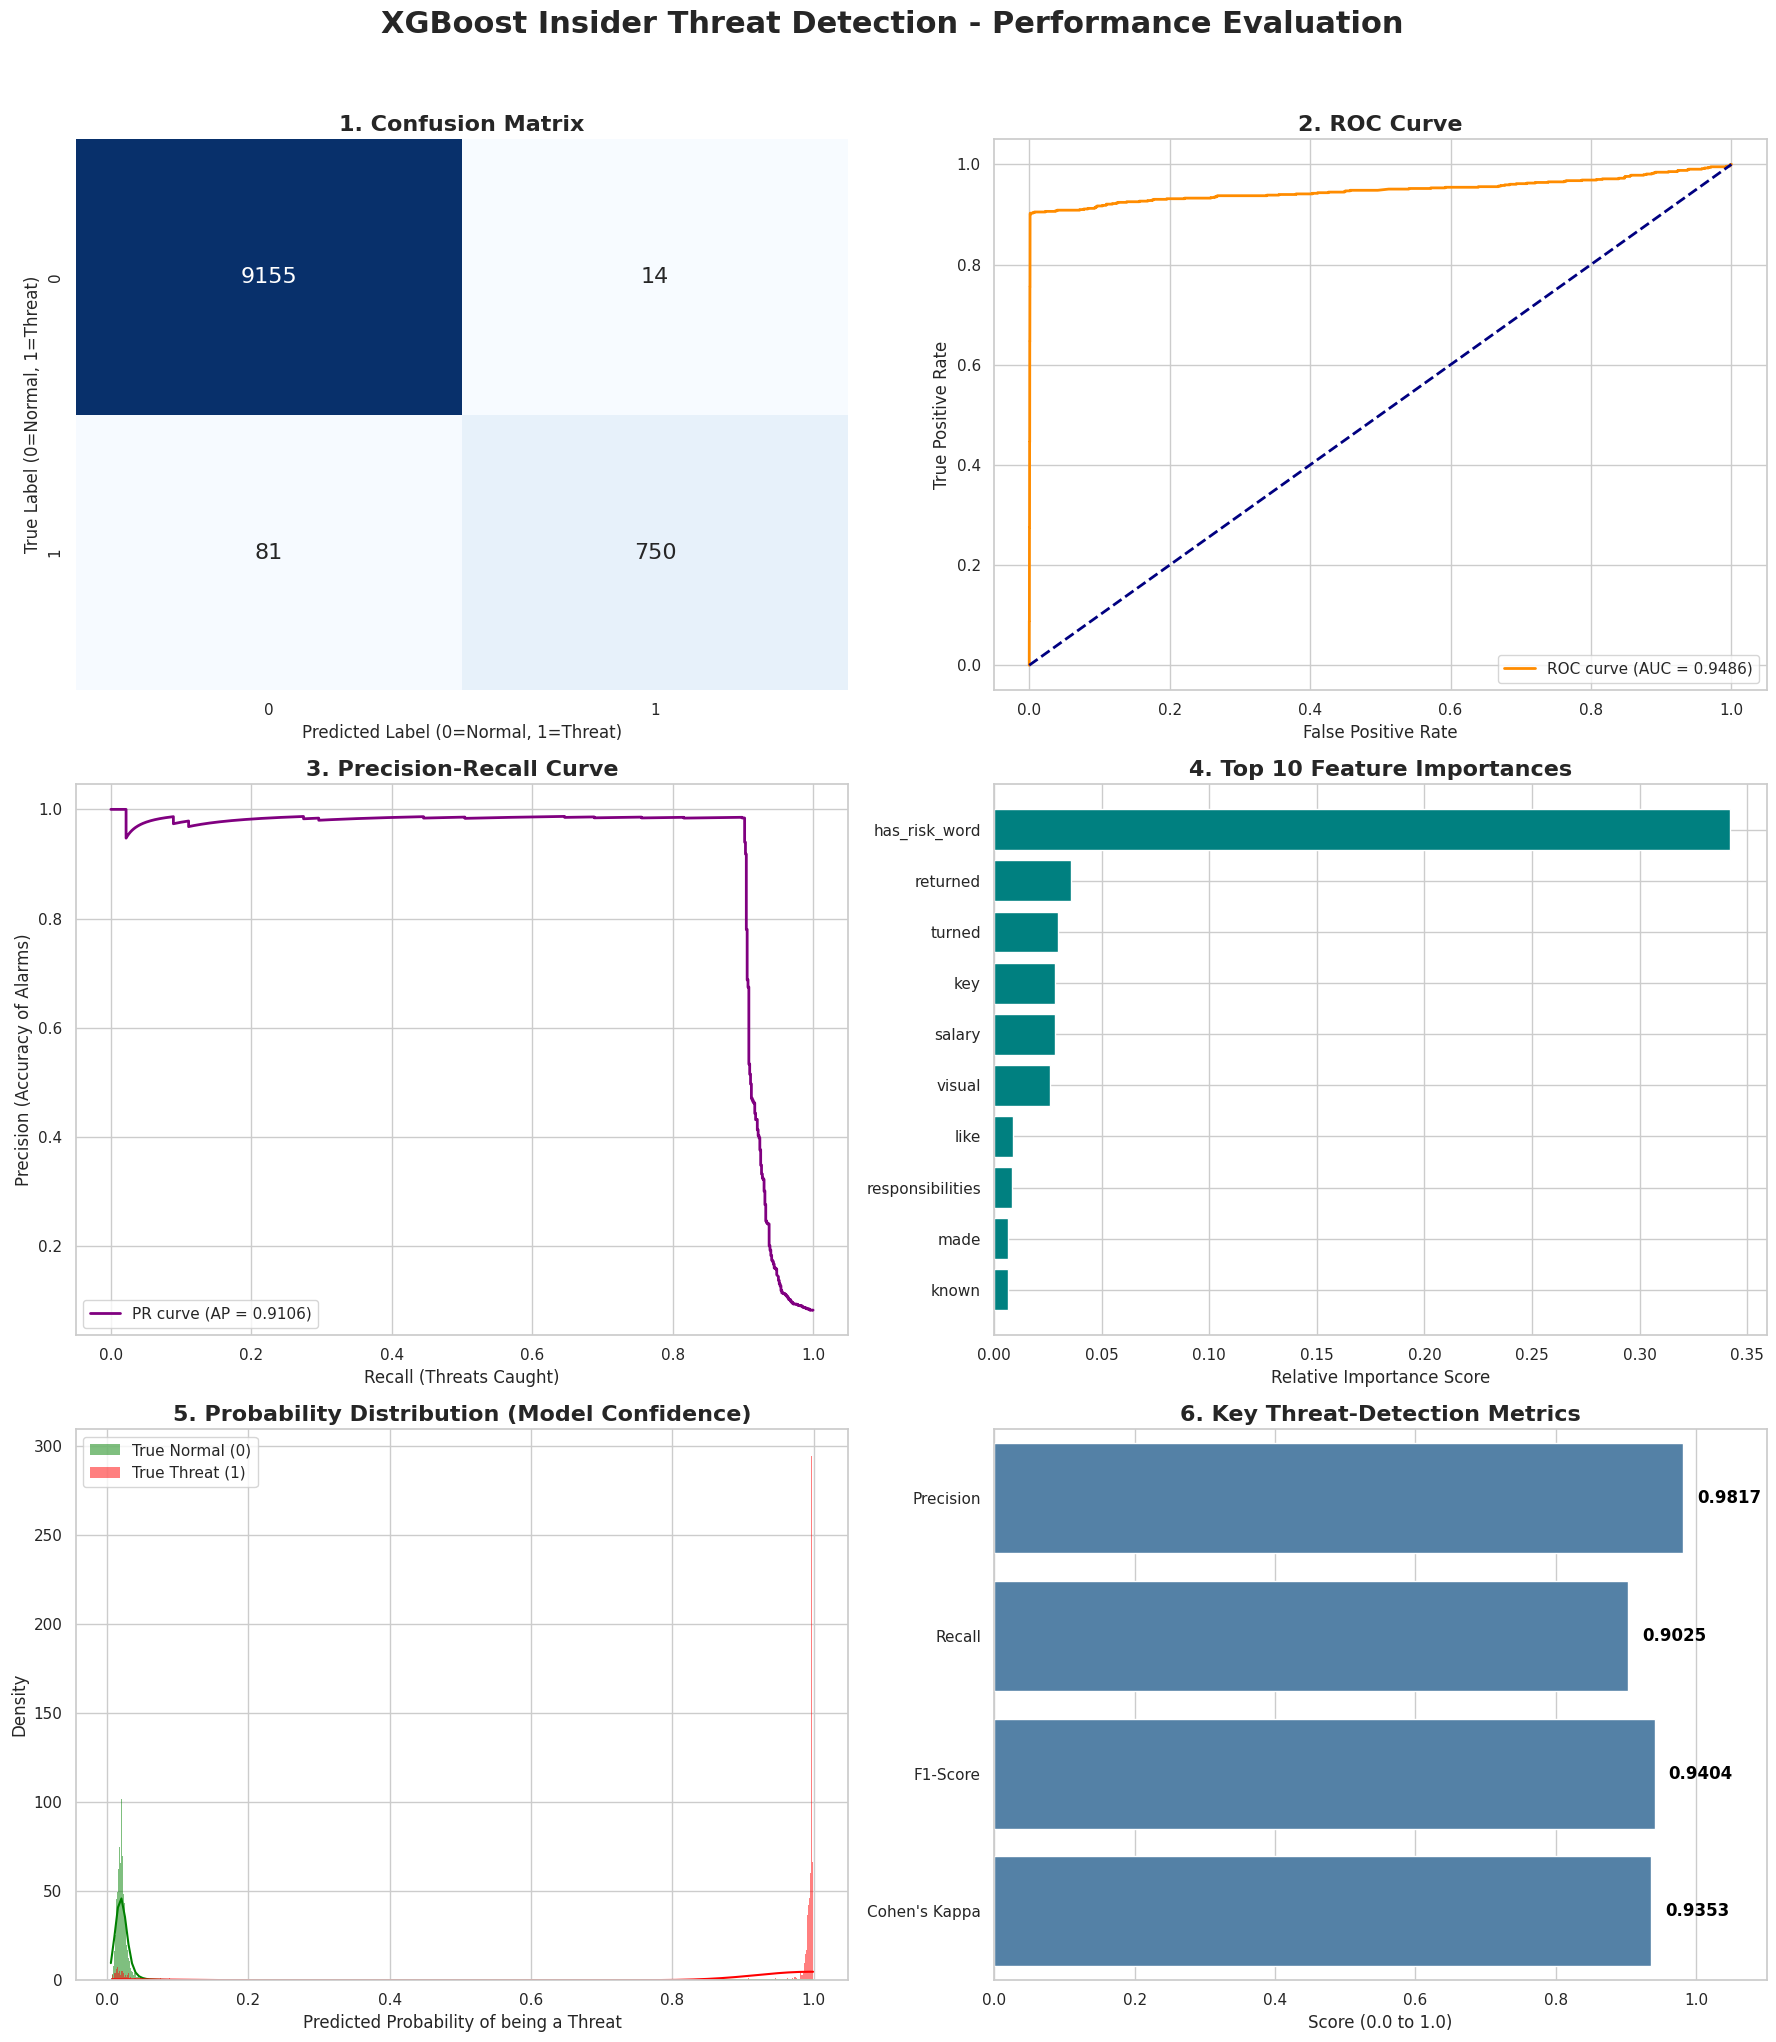

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

# Set the style for academic/professional reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Extract prediction probabilities for advanced curves
y_probs = model.predict_proba(X_test)[:, 1]

# Create a figure with 3x2 subplots (6 graphs total)
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('XGBoost Insider Threat Detection - Performance Evaluation', fontsize=22, fontweight='bold', y=1.02)

# ==========================================
# 1. CONFUSION MATRIX HEATMAP
# ==========================================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False, annot_kws={"size": 16})
axes[0, 0].set_title('1. Confusion Matrix', fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label (0=Normal, 1=Threat)')
axes[0, 0].set_ylabel('True Label (0=Normal, 1=Threat)')

# ==========================================
# 2. ROC CURVE (Receiver Operating Characteristic)
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('2. ROC Curve', fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

# ==========================================
# 3. PRECISION-RECALL CURVE
# ==========================================
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
axes[1, 0].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
axes[1, 0].set_title('3. Precision-Recall Curve', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Recall (Threats Caught)')
axes[1, 0].set_ylabel('Precision (Accuracy of Alarms)')
axes[1, 0].legend(loc="lower left")

# ==========================================
# 4. TOP 10 FEATURE IMPORTANCES
# ==========================================
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]
feature_names = X_test.columns if hasattr(X_test, 'columns') else [f"Feature {i}" for i in range(X_test.shape[1])]
top_features = [feature_names[i] for i in indices]

axes[1, 1].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels(top_features)
axes[1, 1].set_title('4. Top 10 Feature Importances', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Relative Importance Score')

# ==========================================
# 5. PREDICTION PROBABILITY DISTRIBUTION
# ==========================================
# Shows how confidently the model separates normal emails from threats
sns.histplot(y_probs[y_test == 0], color='green', label='True Normal (0)', kde=True, stat="density", linewidth=0, ax=axes[2, 0], alpha=0.5)
sns.histplot(y_probs[y_test == 1], color='red', label='True Threat (1)', kde=True, stat="density", linewidth=0, ax=axes[2, 0], alpha=0.5)
axes[2, 0].set_title('5. Probability Distribution (Model Confidence)', fontsize=16, fontweight='bold')
axes[2, 0].set_xlabel('Predicted Probability of being a Threat')
axes[2, 0].set_ylabel('Density')
axes[2, 0].legend()

# ==========================================
# 6. KEY METRICS SUMMARY
# ==========================================
# Uses the exact metrics generated by your model evaluation
from sklearn.metrics import precision_score, recall_score, f1_score
p_score = precision_score(y_test, y_pred)
r_score = recall_score(y_test, y_pred)
f_score = f1_score(y_test, y_pred)

metrics = ['Precision', 'Recall', 'F1-Score', "Cohen's Kappa"]
values = [p_score, r_score, f_score, kappa]

sns.barplot(x=values, y=metrics, color='steelblue', ax=axes[2, 1])
for i, v in enumerate(values):
    axes[2, 1].text(v + 0.02, i, f"{v:.4f}", color='black', va='center', fontweight='bold')
axes[2, 1].set_xlim(0, 1.1)
axes[2, 1].set_title('6. Key Threat-Detection Metrics', fontsize=16, fontweight='bold')
axes[2, 1].set_xlabel('Score (0.0 to 1.0)')

# Render the plots
plt.tight_layout()
plt.show()

Generating Summary Plot...


/tmp/ipykernel_2012/1111380580.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar")


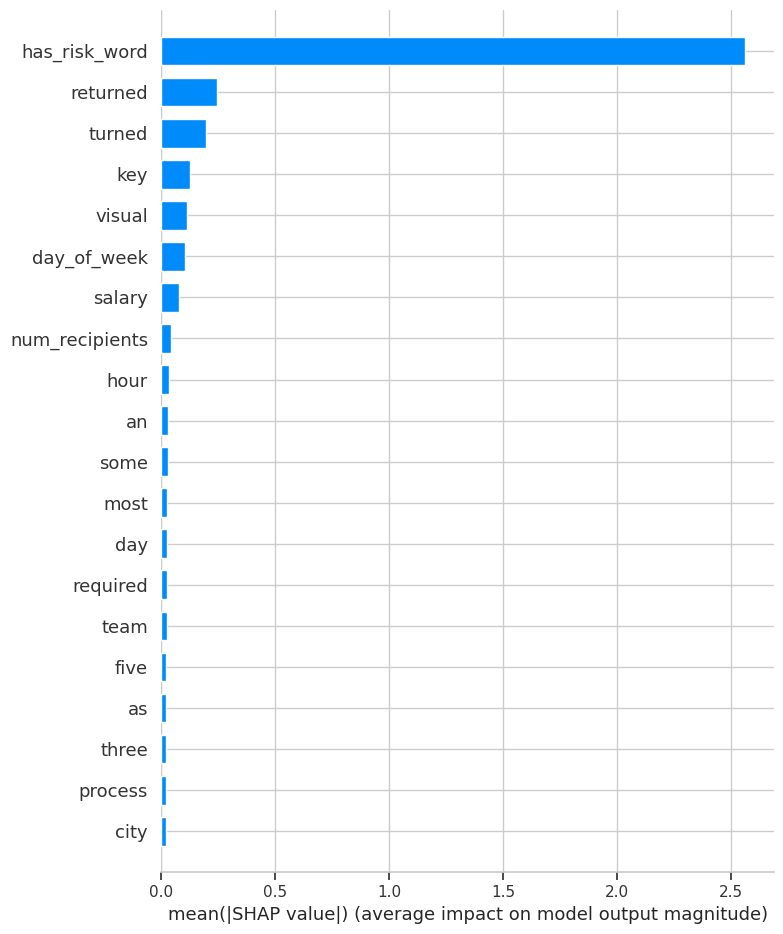


Explaining Threat at Row 18 (Confidence: 1.00)


In [ ]:
import shap
import matplotlib.pyplot as plt


X_sample = X_test.iloc[:50]


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)


print("Generating Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar")


probs = model.predict_proba(X_sample)[:, 1]
threat_indices = np.where(probs > 0.5)[0]

if len(threat_indices) > 0:
    idx = threat_indices[0]
    print(f"\nExplaining Threat at Row {idx} (Confidence: {probs[idx]:.2f})")

    # Simple Force Plot (XGBoost makes this easy)
    shap.initjs()
    display(shap.force_plot(
        explainer.expected_value,
        shap_values[idx],
        X_sample.iloc[idx]
    ))
else:
    print("No threats found in this sample.")

Generating SHAP Global Summary Plot...


/tmp/ipykernel_2012/2040636689.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_global, X_sample_global)


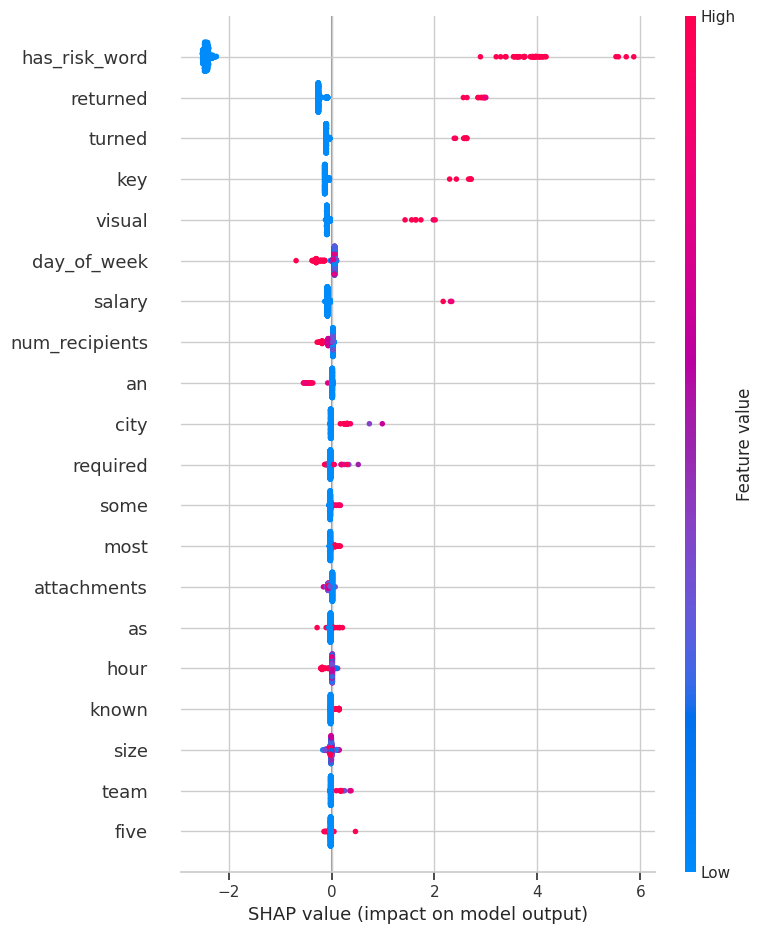


Searching for a successfully caught threat (True Positive) to explain...

Explaining True Positive Threat at Test Index 18 (Confidence: 1.00)


In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# --- 1. GLOBAL EXPLANATION (How the model thinks overall) ---
print("Generating SHAP Global Summary Plot...")
# Use a slightly larger random sample to get a true picture of feature importance
X_sample_global = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values_global = explainer.shap_values(X_sample_global)

plt.figure(figsize=(10, 6))
# Removing plot_type="bar" creates a beeswarm plot.
shap.summary_plot(shap_values_global, X_sample_global)


# --- 2. LOCAL EXPLANATION (Deep dive into a specific caught threat) ---
print("\nSearching for a successfully caught threat (True Positive) to explain...")

# Find indices where it was ACTUALLY a threat AND the XGBoost model CAUGHT it
y_test_array = np.array(y_test)
true_positives = np.where((y_test_array == 1) & (y_pred == 1))[0]

if len(true_positives) > 0:
    # Take the first successfully caught threat
    idx = true_positives[0]

    # FIX: Use double brackets [[idx]] to extract a 2D DataFrame instead of a 1D Series
    row_df = X_test.iloc[[idx]]

    # Calculate confidence using the 2D DataFrame
    prob = model.predict_proba(row_df)[0, 1]

    print(f"\nExplaining True Positive Threat at Test Index {idx} (Confidence: {prob:.2f})")

    # Generate the Force Plot for this specific threat
    shap.initjs()

    # Pass the 2D DataFrame to the explainer
    shap_values_local = explainer.shap_values(row_df)

    display(shap.force_plot(
        explainer.expected_value,
        shap_values_local[0],  # Extract the 1D SHAP values for the plot
        row_df.iloc[0]         # Pass the 1D Series for the feature labels
    ))
else:
    print("No True Positives found to explain.")

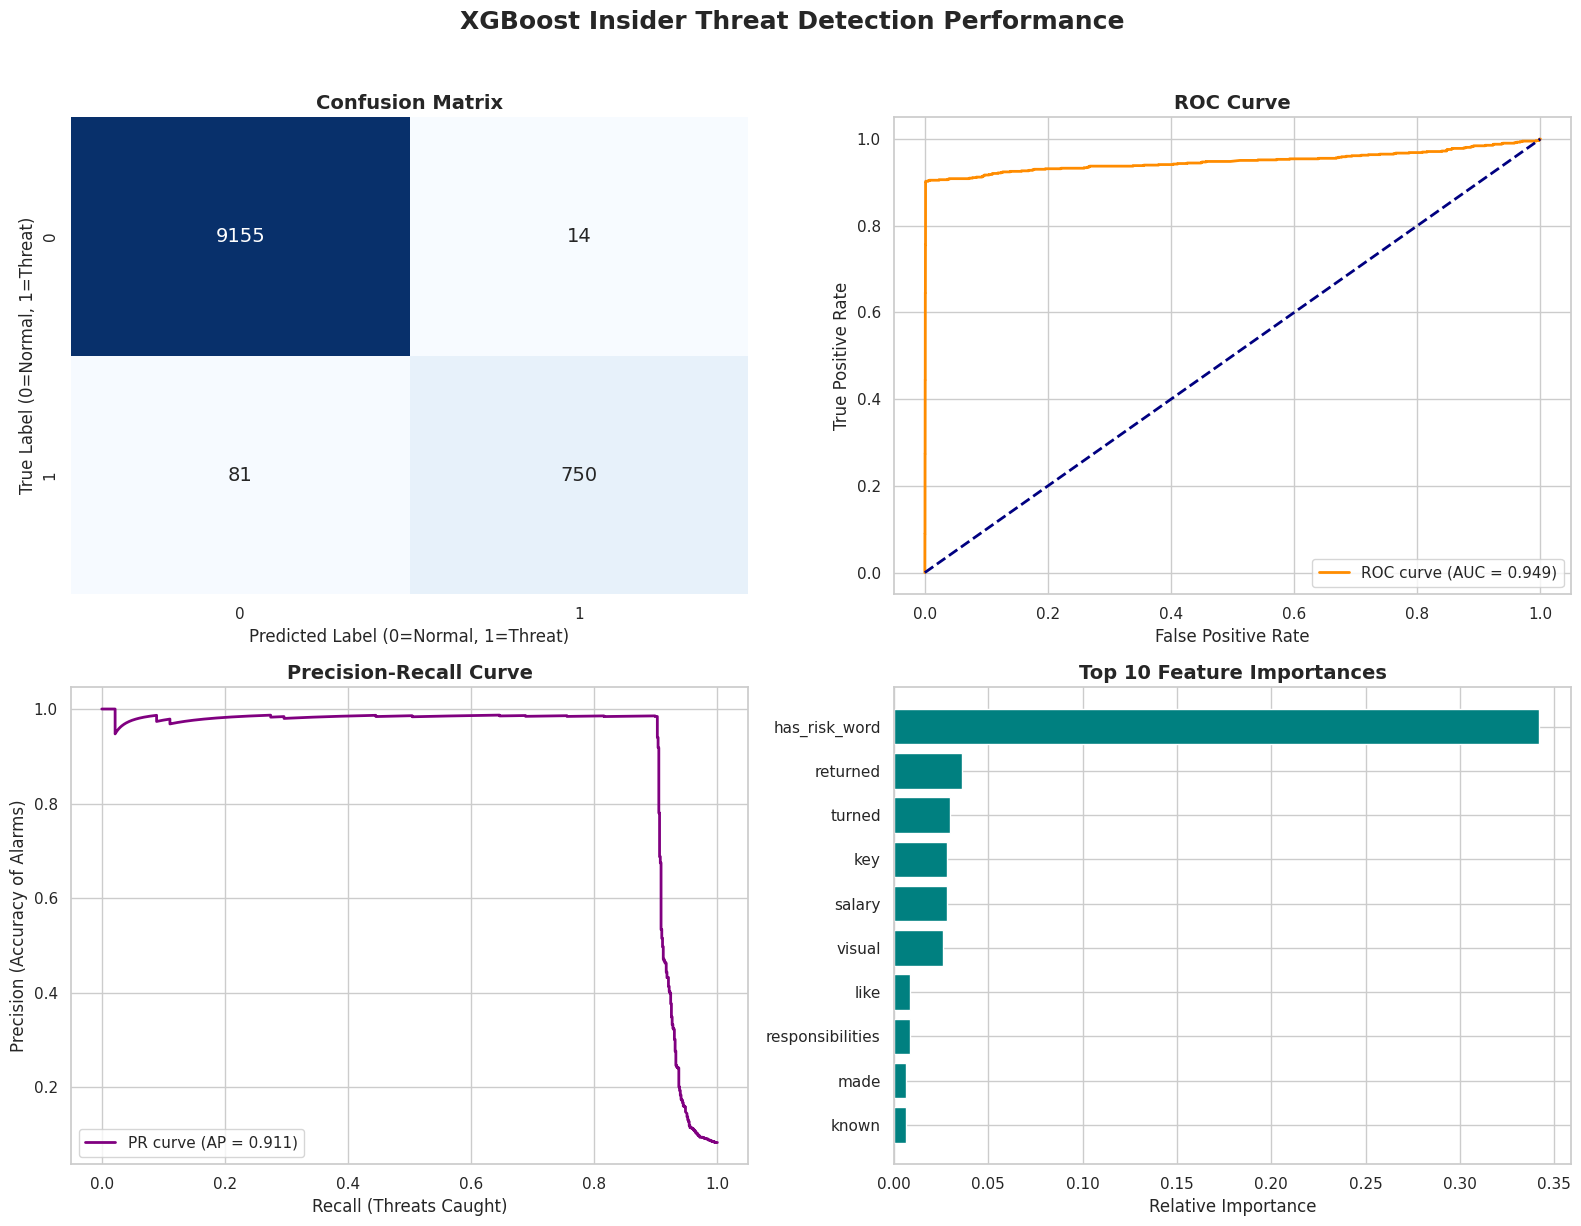

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

# Set the style for academic-looking plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# We need the probabilities for the ROC and PR curves
y_probs = model.predict_proba(X_test)[:, 1]

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost Insider Threat Detection Performance', fontsize=18, fontweight='bold', y=1.02)

# ==========================================
# 1. CONFUSION MATRIX HEATMAP
# ==========================================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False, annot_kws={"size": 14})
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label (0=Normal, 1=Threat)')
axes[0, 0].set_ylabel('True Label (0=Normal, 1=Threat)')

# ==========================================
# 2. ROC CURVE (Receiver Operating Characteristic)
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

# ==========================================
# 3. PRECISION-RECALL CURVE (Crucial for Imbalanced Data)
# ==========================================
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

axes[1, 0].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Recall (Threats Caught)')
axes[1, 0].set_ylabel('Precision (Accuracy of Alarms)')
axes[1, 0].legend(loc="lower left")

# ==========================================
# 4. TOP 10 FEATURE IMPORTANCE
# ==========================================
# Get feature importances from XGBoost
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] # Get top 10

axes[1, 1].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[1, 1].set_yticks(range(len(indices)))
# Safely get feature names if available, otherwise use indices
if hasattr(X, 'columns'):
    axes[1, 1].set_yticklabels([X.columns[i] for i in indices])
else:
    axes[1, 1].set_yticklabels([f"Feature {i}" for i in indices])
axes[1, 1].set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Relative Importance')

# Adjust layout and show
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
import time

print("Setting up the Stacking Ensemble...")

# 1. Define the Base Models (Level 0)
# We use the configurations that we know already work well
base_models = [
    ('xgb', XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100, random_state=42))
]

# 2. Define the Meta-Model (Level 1)
# Logistic Regression is the standard for classification stacking
meta_model = LogisticRegression()

# 3. Build the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5 # 5-fold cross-validation during training to prevent overfitting
)

# 4. Train the Ensemble (This will take a little longer!)
print("Training the Stacking Classifier on balanced SMOTE data...")
print("(Note: Stacking trains multiple models multiple times, this may take a few minutes)")
start_time = time.time()

stacking_clf.fit(X_train_res, y_train_res)

print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# 5. Evaluate
print("\nPredicting on test set...")
y_pred_stack = stacking_clf.predict(X_test)

print("\n--- STACKING ENSEMBLE FINAL RESULTS ---")
print(classification_report(y_test, y_pred_stack))

kappa_stack = cohen_kappa_score(y_test, y_pred_stack)
print(f"Cohen's Kappa (Stacking): {kappa_stack:.4f}")

cm_stack = confusion_matrix(y_test, y_pred_stack)
print(f"\nThreats Caught: {cm_stack[1][1]} out of {cm_stack[1][0] + cm_stack[1][1]}")
print(f"False Alarms: {cm_stack[0][1]}")

Setting up the Stacking Ensemble...
Training the Stacking Classifier on balanced SMOTE data...
(Note: Stacking trains multiple models multiple times, this may take a few minutes)


KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
import time

print("Setting up the High-Speed Voting Ensemble...")

# 1. Define Base Models
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss')
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

# Added early_stopping=True to guarantee the MLP does not hang Colab again
mlp_model = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=50, early_stopping=True, random_state=42)

# 2. Build the Voting Classifier (Soft voting uses probabilities for better accuracy)
voting_clf = VotingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model), ('mlp', mlp_model)],
    voting='soft'
)

# 3. Train
print("Training Voting Ensemble...")
start_time = time.time()
voting_clf.fit(X_train_res, y_train_res)
print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

# 4. Evaluate
print("\nPredicting on test set...")
y_pred_vote = voting_clf.predict(X_test)

print("\n--- VOTING ENSEMBLE FINAL RESULTS ---")
print(classification_report(y_test, y_pred_vote))

kappa_vote = cohen_kappa_score(y_test, y_pred_vote)
print(f"Cohen's Kappa (Voting): {kappa_vote:.4f}")

cm_vote = confusion_matrix(y_test, y_pred_vote)
print(f"\nThreats Caught: {cm_vote[1][1]} out of {cm_vote[1][0] + cm_vote[1][1]}")
print(f"False Alarms: {cm_vote[0][1]}")

Setting up the High-Speed Voting Ensemble...
Training Voting Ensemble...
Training completed in 149.66 seconds.

Predicting on test set...

--- VOTING ENSEMBLE FINAL RESULTS ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9169
           1       0.89      0.90      0.90       831

    accuracy                           0.98     10000
   macro avg       0.94      0.95      0.94     10000
weighted avg       0.98      0.98      0.98     10000

Cohen's Kappa (Voting): 0.8885

Threats Caught: 751 out of 831
False Alarms: 91


In [ ]:
import pandas as pd
import numpy as np

# =======================================================
# 1. DEFINE THE LIVE TESTING FUNCTION FOR THE ENSEMBLE
# =======================================================
def predict_custom_emails_ensemble(email_list, trained_tfidf, trained_ensemble_model):
    print("Processing custom emails through Voting Ensemble...\n" + "="*50)

    # Convert custom emails to DataFrame
    df_custom = pd.DataFrame(email_list)

    # Extract Metadata Features
    df_custom['date'] = pd.to_datetime(df_custom['date'], errors='coerce')
    df_custom['hour'] = df_custom['date'].dt.hour
    df_custom['day_of_week'] = df_custom['date'].dt.dayofweek

    df_custom['to'] = df_custom['to'].fillna('')
    df_custom['cc'] = df_custom['cc'].fillna('')
    df_custom['bcc'] = df_custom['bcc'].fillna('')
    df_custom['num_recipients'] = df_custom['to'].str.count(';') + df_custom['cc'].str.count(';') + df_custom['bcc'].str.count(';') + 1

    # Trigger Risk Heuristics
    risk_keywords = 'visual|turned|confidential|password|key|salary'
    df_custom['has_risk_word'] = df_custom['content'].str.contains(risk_keywords, case=False, na=False).astype(int)

    # Vectorize Text (CRITICAL: Using .transform() on the already fitted tfidf)
    content_tfidf = trained_tfidf.transform(df_custom['content'].fillna('')).toarray()
    content_df = pd.DataFrame(content_tfidf, columns=trained_tfidf.get_feature_names_out())

    # Combine Features in the exact order the model expects
    df_custom['size'] = df_custom.get('size', 1500) # Default size if missing
    df_custom['attachments'] = df_custom.get('attachments', 0) # Default attachments

    numeric_cols = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week', 'has_risk_word']
    X_numeric = df_custom[numeric_cols].reset_index(drop=True)

    X_custom = pd.concat([X_numeric, content_df], axis=1)
    X_custom = X_custom.loc[:, ~X_custom.columns.duplicated()]

    # Make Predictions using the Voting Ensemble
    predictions = trained_ensemble_model.predict(X_custom)
    probabilities = trained_ensemble_model.predict_proba(X_custom)[:, 1]

    # Output Results
    for i in range(len(df_custom)):
        status = "🚨 THREAT DETECTED" if predictions[i] == 1 else "✅ NORMAL EMAIL"
        print(f"Email {i+1} Snippet: '{df_custom['content'].iloc[i][:75]}...'")
        print(f"Prediction:  {status}")
        print(f"Confidence:  {probabilities[i]*100:.2f}%\n" + "-"*50)

# =======================================================
# 2. CREATE FAKE EMAILS TO TEST
# =======================================================
live_test_data = [
    {
        "date": "2026-04-20 10:15:00",
        "to": "colleague@company.com",
        "cc": "",
        "bcc": "",
        "content": "Hey Sarah, are we still on for the marketing meeting at noon? Let me know.",
        "size": 450,
        "attachments": 0
    },
    {
        "date": "2026-04-20 02:45:00",
        "to": "personal_account@gmail.com",
        "cc": "",
        "bcc": "external_competitor@protonmail.com",
        "content": "Attached are the confidential salary reports and the visual source code files for the new project as requested.",
        "size": 45000,
        "attachments": 2
    }
]

# =======================================================
# 3. RUN THE TEST
# =======================================================
# Using 'tfidf' from earlier and 'voting_clf' from your ensemble script
predict_custom_emails_ensemble(live_test_data, tfidf, voting_clf)

Processing custom emails through Voting Ensemble...
Email 1 Snippet: 'Hey Sarah, are we still on for the marketing meeting at noon? Let me know....'
Prediction:  ✅ NORMAL EMAIL
Confidence:  22.53%
--------------------------------------------------
Email 2 Snippet: 'Attached are the confidential salary reports and the visual source code fil...'
Prediction:  🚨 THREAT DETECTED
Confidence:  86.81%
--------------------------------------------------


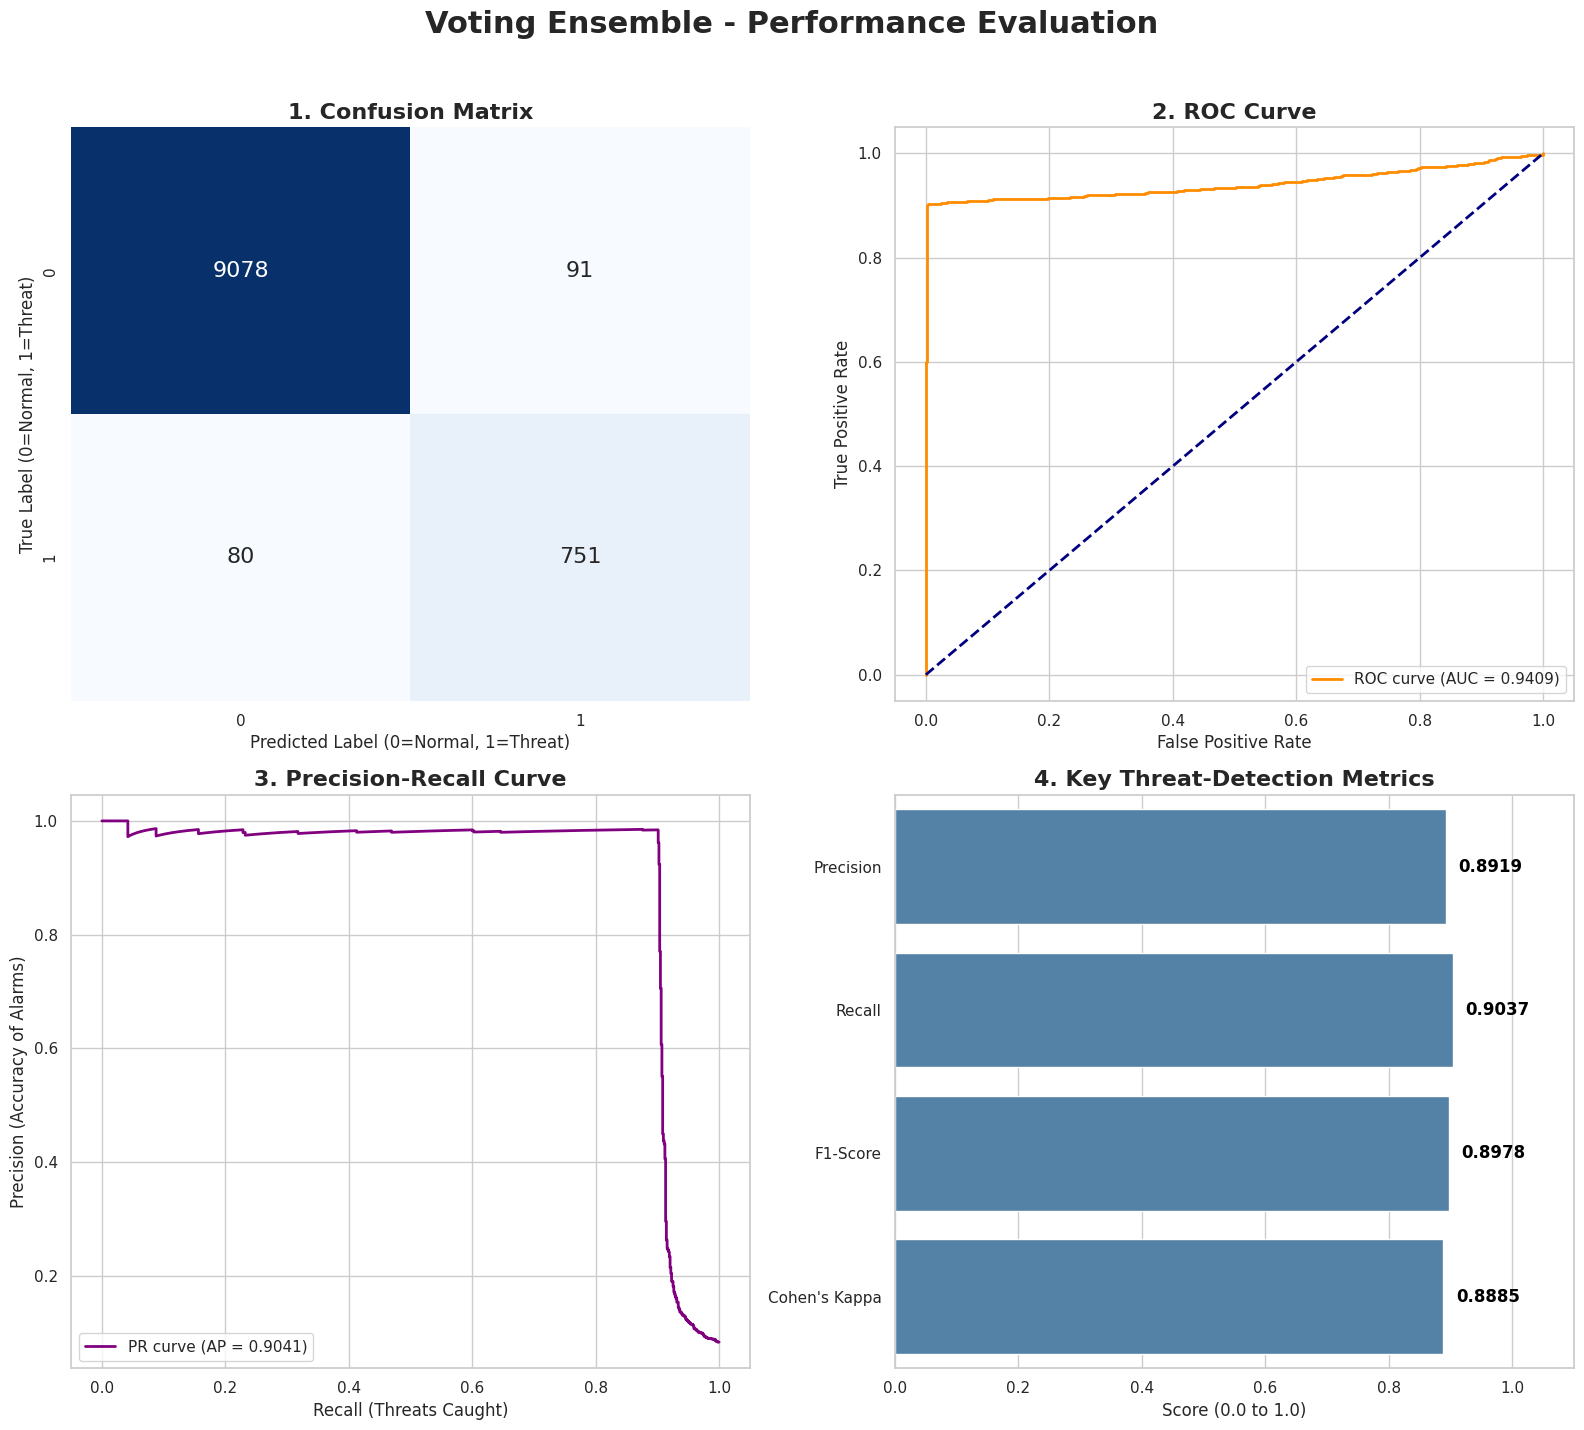

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score
import numpy as np

# Set the style for academic/professional reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Extract prediction probabilities from the Voting Classifier
y_probs_vote = voting_clf.predict_proba(X_test)[:, 1]

# Create a figure with 2x2 subplots (4 graphs total)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Voting Ensemble - Performance Evaluation', fontsize=22, fontweight='bold', y=1.02)

# ==========================================
# 1. CONFUSION MATRIX HEATMAP
# ==========================================
cm_vote = confusion_matrix(y_test, y_pred_vote)
sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False, annot_kws={"size": 16})
axes[0, 0].set_title('1. Confusion Matrix', fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label (0=Normal, 1=Threat)')
axes[0, 0].set_ylabel('True Label (0=Normal, 1=Threat)')

# ==========================================
# 2. ROC CURVE
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_probs_vote)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('2. ROC Curve', fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

# ==========================================
# 3. PRECISION-RECALL CURVE
# ==========================================
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probs_vote)
pr_auc = average_precision_score(y_test, y_probs_vote)
axes[1, 0].plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
axes[1, 0].set_title('3. Precision-Recall Curve', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Recall (Threats Caught)')
axes[1, 0].set_ylabel('Precision (Accuracy of Alarms)')
axes[1, 0].legend(loc="lower left")

# ==========================================
# 4. KEY METRICS SUMMARY
# ==========================================
p_score = precision_score(y_test, y_pred_vote)
r_score = recall_score(y_test, y_pred_vote)
f_score = f1_score(y_test, y_pred_vote)

metrics = ['Precision', 'Recall', 'F1-Score', "Cohen's Kappa"]
values = [p_score, r_score, f_score, kappa_vote]

sns.barplot(x=values, y=metrics, color='steelblue', ax=axes[1, 1])
for i, v in enumerate(values):
    axes[1, 1].text(v + 0.02, i, f"{v:.4f}", color='black', va='center', fontweight='bold')
axes[1, 1].set_xlim(0, 1.1)
axes[1, 1].set_title('4. Key Threat-Detection Metrics', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Score (0.0 to 1.0)')

# Render the plots
plt.tight_layout()
plt.show()

Generating Advanced XAI Visualizations for Report...

1. Generating SHAP Dependence Plot for 'hour'...


<Figure size 1000x600 with 0 Axes>

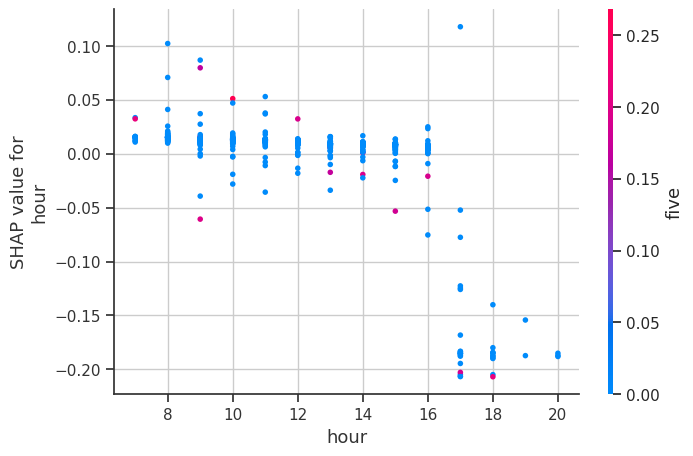


2. Generating SHAP Decision Plot for a True Positive...


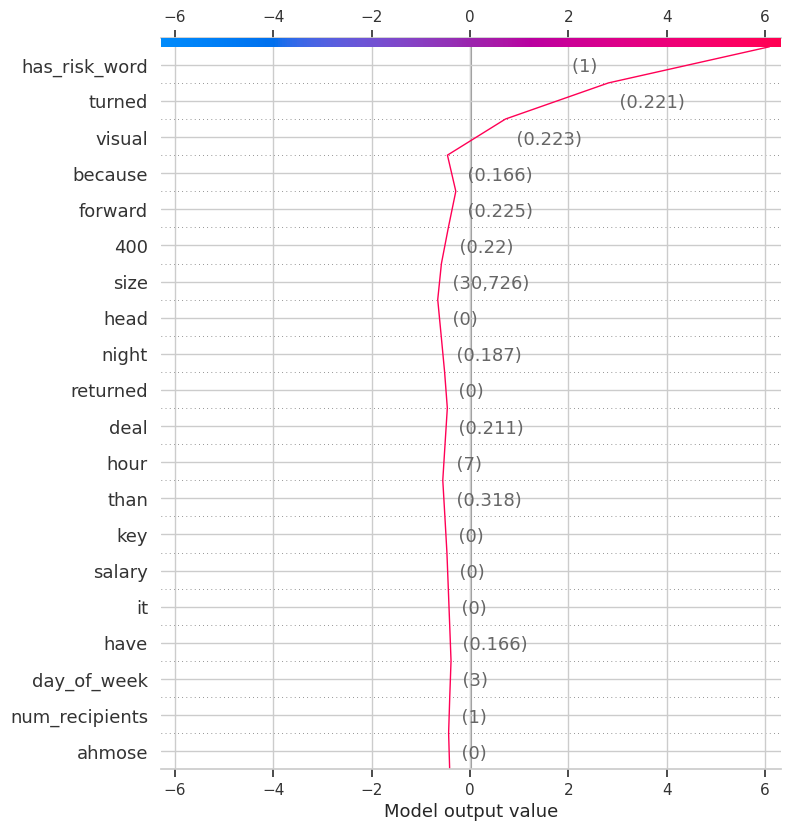

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Generating Advanced XAI Visualizations for Report...")

# --- 1. SHAP DEPENDENCE PLOT ---
print("\n1. Generating SHAP Dependence Plot for 'hour'...")
plt.figure(figsize=(10, 6))
shap.dependence_plot("hour", shap_values_global, X_sample_global, show=True)

# --- 2. SHAP DECISION PLOT ---
print("\n2. Generating SHAP Decision Plot for a True Positive...")
true_positives = np.where((np.array(y_test) == 1) & (y_pred == 1))[0]

if len(true_positives) > 0:
    idx = true_positives[0]
    row_df = X_test.iloc[[idx]]

    # Calculate SHAP values for this specific threat
    shap_values_local = explainer.shap_values(row_df)

    plt.figure(figsize=(10, 8))
    # Removed plot_color to avoid the Matplotlib colormap crash
    shap.decision_plot(
        explainer.expected_value,
        shap_values_local[0],
        row_df.iloc[0],
        feature_names=X_test.columns.tolist()
    )
    plt.show()
else:
    print("No True Positives found to explain.")

--- XGBOOST FINAL RESULTS ---
Accuracy:  0.9905 (How many total did we get right?)
Precision: 0.9817 (how often are we right?)
Recall:    0.9025 (Did we catch all the threats?)
F1 Score:  0.9404 (balance between Precision and Recall)
ROC AUC:   0.9505 (Overall distinction ability)
------------------------------

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9169
           1       0.98      0.90      0.94       831

    accuracy                           0.99     10000
   macro avg       0.99      0.95      0.97     10000
weighted avg       0.99      0.99      0.99     10000



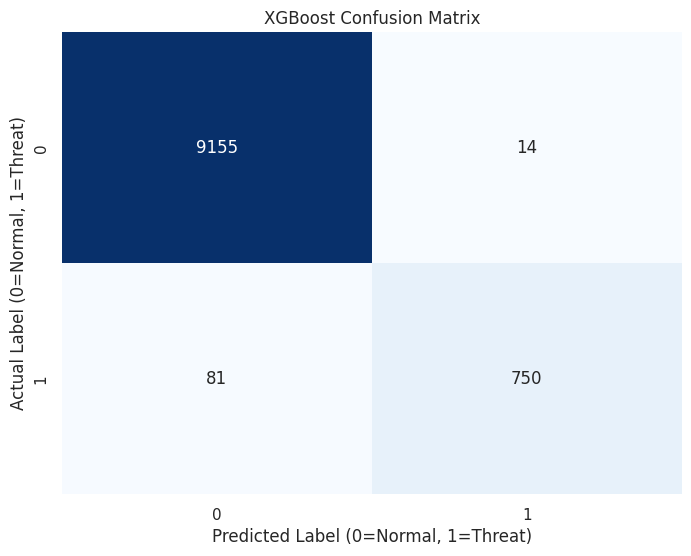

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CALCULATE METRICS ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("--- XGBOOST FINAL RESULTS ---")
print(f"Accuracy:  {accuracy:.4f} (How many total did we get right?)")
print(f"Precision: {precision:.4f} (how often are we right?)")
print(f"Recall:    {recall:.4f} (Did we catch all the threats?)")
print(f"F1 Score:  {f1:.4f} (balance between Precision and Recall)")
print(f"ROC AUC:   {auc:.4f} (Overall distinction ability)")
print("-" * 30)

# --- 2. DETAILED REPORT ---
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# --- 3. VISUALIZE CONFUSION MATRIX ---
# This shows exactly where the mistakes happened
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label (0=Normal, 1=Threat)')
plt.ylabel('Actual Label (0=Normal, 1=Threat)')
plt.show()

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix

print("1. Defining base models...")
# Using lightweight parameters to minimize computational power
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss', n_jobs=-1)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(30,), max_iter=50, random_state=42))
]

print("2. Building Stacking Ensemble...")
# Logistic Regression acts as the fast, efficient "CEO" meta-model
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=3, # Reduced cross-validation folds to save compute time
    n_jobs=-1
)

print("3. Training Stacking Ensemble on balanced SMOTE data...")
stacking_model.fit(X_train_res, y_train_res)

print("4. Evaluating on Test Data...")
y_pred_stack = stacking_model.predict(X_test)

print("\n--- STACKING ENSEMBLE FINAL RESULTS ---")
print(classification_report(y_test, y_pred_stack))

kappa_stack = cohen_kappa_score(y_test, y_pred_stack)
print(f"Cohen's Kappa (Stacking): {kappa_stack:.4f}")

cm_stack = confusion_matrix(y_test, y_pred_stack)
print(f"\nThreats Caught (True Positives): {cm_stack[1][1]} out of {cm_stack[1][0] + cm_stack[1][1]}")
print(f"False Alarms (False Positives):  {cm_stack[0][1]}")

1. Defining base models...
2. Building Stacking Ensemble...
3. Training Stacking Ensemble on balanced SMOTE data...


In [ ]:
import pandas as pd
import numpy as np

# =======================================================
# 1. DEFINE THE LIVE TESTING FUNCTION FOR XGBOOST
# =======================================================
def predict_custom_emails_xgboost(email_list, trained_tfidf, trained_xgb_model):
    print("Processing custom emails for live prediction...\n" + "="*50)

    # Convert custom emails to DataFrame
    df_custom = pd.DataFrame(email_list)

    # Extract Metadata Features
    df_custom['date'] = pd.to_datetime(df_custom['date'], errors='coerce')
    df_custom['hour'] = df_custom['date'].dt.hour
    df_custom['day_of_week'] = df_custom['date'].dt.dayofweek

    df_custom['to'] = df_custom['to'].fillna('')
    df_custom['cc'] = df_custom['cc'].fillna('')
    df_custom['bcc'] = df_custom['bcc'].fillna('')
    df_custom['num_recipients'] = df_custom['to'].str.count(';') + df_custom['cc'].str.count(';') + df_custom['bcc'].str.count(';') + 1

    # Trigger Risk Heuristics
    risk_keywords = 'visual|turned|confidential|password|key|salary'
    df_custom['has_risk_word'] = df_custom['content'].str.contains(risk_keywords, case=False, na=False).astype(int)

    # Vectorize Text (CRITICAL: Using .transform() on the already fitted tfidf)
    content_tfidf = trained_tfidf.transform(df_custom['content'].fillna('')).toarray()
    content_df = pd.DataFrame(content_tfidf, columns=trained_tfidf.get_feature_names_out())

    # Combine Features in the exact order the model expects
    df_custom['size'] = df_custom.get('size', 1500) # Default size if missing
    df_custom['attachments'] = df_custom.get('attachments', 0) # Default attachments

    numeric_cols = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week', 'has_risk_word']
    X_numeric = df_custom[numeric_cols].reset_index(drop=True)

    X_custom = pd.concat([X_numeric, content_df], axis=1)
    X_custom = X_custom.loc[:, ~X_custom.columns.duplicated()]

    # Make Predictions using the XGBoost model
    predictions = trained_xgb_model.predict(X_custom)
    probabilities = trained_xgb_model.predict_proba(X_custom)[:, 1]

    # Output Results
    for i in range(len(df_custom)):
        status = "🚨 THREAT DETECTED" if predictions[i] == 1 else "✅ NORMAL EMAIL"
        print(f"Email {i+1} Snippet: '{df_custom['content'].iloc[i][:75]}...'")
        print(f"Prediction:  {status}")
        print(f"Confidence:  {probabilities[i]*100:.2f}%\n" + "-"*50)

# =======================================================
# 2. CREATE FAKE EMAILS TO TEST
# =======================================================
live_test_data = [
    {
        "date": "2026-04-20 10:15:00",
        "to": "colleague@company.com",
        "cc": "",
        "bcc": "",
        "content": "Hey Sarah, are we still on for the marketing meeting at noon? Let me know.",
        "size": 450,
        "attachments": 0
    },
    {
        "date": "2026-04-20 02:45:00",
        "to": "personal_account@gmail.com",
        "cc": "",
        "bcc": "external_competitor@protonmail.com",
        "content": "Attached are the confidential salary reports and the visual source code files for the new project as requested.",
        "size": 45000,
        "attachments": 2
    }
]

# =======================================================
# 3. RUN THE TEST
# =======================================================
# Using 'tfidf' and 'model' as defined in your XGBoost training script
predict_custom_emails_xgboost(live_test_data, tfidf, model)

Processing custom emails for live prediction...
Email 1 Snippet: 'Hey Sarah, are we still on for the marketing meeting at noon? Let me know....'
Prediction:  ✅ NORMAL EMAIL
Confidence:  2.20%
--------------------------------------------------
Email 2 Snippet: 'Attached are the confidential salary reports and the visual source code fil...'
Prediction:  🚨 THREAT DETECTED
Confidence:  99.72%
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np

# =======================================================
# 1. DEFINE THE LIVE TESTING FUNCTION FOR THE ENSEMBLE
# =======================================================
def predict_custom_emails_ensemble(email_list, trained_tfidf, trained_ensemble_model):
    print("Processing custom emails through Voting Ensemble...\n" + "="*50)

    # Convert custom emails to DataFrame
    df_custom = pd.DataFrame(email_list)

    # Extract Metadata Features
    df_custom['date'] = pd.to_datetime(df_custom['date'], errors='coerce')
    df_custom['hour'] = df_custom['date'].dt.hour
    df_custom['day_of_week'] = df_custom['date'].dt.dayofweek

    df_custom['to'] = df_custom['to'].fillna('')
    df_custom['cc'] = df_custom['cc'].fillna('')
    df_custom['bcc'] = df_custom['bcc'].fillna('')
    df_custom['num_recipients'] = df_custom['to'].str.count(';') + df_custom['cc'].str.count(';') + df_custom['bcc'].str.count(';') + 1

    # Trigger Risk Heuristics
    risk_keywords = 'visual|turned|confidential|password|key|salary'
    df_custom['has_risk_word'] = df_custom['content'].str.contains(risk_keywords, case=False, na=False).astype(int)

    # Vectorize Text (CRITICAL: Using .transform() on the already fitted tfidf)
    content_tfidf = trained_tfidf.transform(df_custom['content'].fillna('')).toarray()
    content_df = pd.DataFrame(content_tfidf, columns=trained_tfidf.get_feature_names_out())

    # Combine Features in the exact order the model expects
    df_custom['size'] = df_custom.get('size', 1500) # Default size if missing
    df_custom['attachments'] = df_custom.get('attachments', 0) # Default attachments

    numeric_cols = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week', 'has_risk_word']
    X_numeric = df_custom[numeric_cols].reset_index(drop=True)

    X_custom = pd.concat([X_numeric, content_df], axis=1)
    X_custom = X_custom.loc[:, ~X_custom.columns.duplicated()]

    # Make Predictions using the Voting Ensemble
    predictions = trained_ensemble_model.predict(X_custom)
    probabilities = trained_ensemble_model.predict_proba(X_custom)[:, 1]

    # Output Results
    for i in range(len(df_custom)):
        status = "🚨 THREAT DETECTED" if predictions[i] == 1 else "✅ NORMAL EMAIL"
        print(f"Email {i+1} Snippet: '{df_custom['content'].iloc[i][:75]}...'")
        print(f"Prediction:  {status}")
        print(f"Confidence:  {probabilities[i]*100:.2f}%\n" + "-"*50)

# =======================================================
# 2. CREATE FAKE EMAILS TO TEST
# =======================================================
live_test_data = [
    {
        "date": "2026-04-20 10:15:00",
        "to": "colleague@company.com",
        "cc": "",
        "bcc": "",
        "content": "Hey Sarah, are we still on for the marketing meeting at noon? Let me know.",
        "size": 450,
        "attachments": 0
    },
    {
        "date": "2026-04-20 02:45:00",
        "to": "personal_account@gmail.com",
        "cc": "",
        "bcc": "external_competitor@protonmail.com",
        "content": "Attached are the confidential salary reports and the visual source code files for the new project as requested.",
        "size": 45000,
        "attachments": 2
    }
]

# =======================================================
# 3. RUN THE TEST
# =======================================================
# Using 'tfidf' from earlier and 'voting_clf' from your ensemble script
predict_custom_emails_ensemble(live_test_data, tfidf, voting_clf)

Processing custom emails through Voting Ensemble...
Email 1 Snippet: 'Hey Sarah, are we still on for the marketing meeting at noon? Let me know....'
Prediction:  ✅ NORMAL EMAIL
Confidence:  22.53%
--------------------------------------------------
Email 2 Snippet: 'Attached are the confidential salary reports and the visual source code fil...'
Prediction:  🚨 THREAT DETECTED
Confidence:  86.81%
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np

# =======================================================
# 1. DEFINE THE LIVE TESTING FUNCTION FOR XGBOOST
# =======================================================
def predict_custom_emails_xgboost(email_list, trained_tfidf, trained_xgb_model):
    print("Processing custom emails for live prediction...\n" + "="*50)

    # Convert custom emails to DataFrame
    df_custom = pd.DataFrame(email_list)

    # Extract Metadata Features
    df_custom['date'] = pd.to_datetime(df_custom['date'], errors='coerce')
    df_custom['hour'] = df_custom['date'].dt.hour
    df_custom['day_of_week'] = df_custom['date'].dt.dayofweek

    df_custom['to'] = df_custom['to'].fillna('')
    df_custom['cc'] = df_custom['cc'].fillna('')
    df_custom['bcc'] = df_custom['bcc'].fillna('')
    df_custom['num_recipients'] = df_custom['to'].str.count(';') + df_custom['cc'].str.count(';') + df_custom['bcc'].str.count(';') + 1

    # Trigger Risk Heuristics
    risk_keywords = 'visual|turned|confidential|password|key|salary'
    df_custom['has_risk_word'] = df_custom['content'].str.contains(risk_keywords, case=False, na=False).astype(int)

    # Vectorize Text (CRITICAL: Using .transform() on the already fitted tfidf)
    content_tfidf = trained_tfidf.transform(df_custom['content'].fillna('')).toarray()
    content_df = pd.DataFrame(content_tfidf, columns=trained_tfidf.get_feature_names_out())

    # Combine Features in the exact order the model expects
    df_custom['size'] = df_custom.get('size', 1500) # Default size if missing
    df_custom['attachments'] = df_custom.get('attachments', 0) # Default attachments

    numeric_cols = ['size', 'attachments', 'num_recipients', 'hour', 'day_of_week', 'has_risk_word']
    X_numeric = df_custom[numeric_cols].reset_index(drop=True)

    X_custom = pd.concat([X_numeric, content_df], axis=1)
    X_custom = X_custom.loc[:, ~X_custom.columns.duplicated()]

    # Make Predictions using the XGBoost model
    predictions = trained_xgb_model.predict(X_custom)
    probabilities = trained_xgb_model.predict_proba(X_custom)[:, 1]

    # Output Results
    for i in range(len(df_custom)):
        status = "🚨 THREAT DETECTED" if predictions[i] == 1 else "✅ NORMAL EMAIL"
        print(f"Email {i+1} Snippet: '{df_custom['content'].iloc[i][:75]}...'")
        print(f"Prediction:  {status}")
        print(f"Threat Probability:  {probabilities[i]*100:.2f}%\n" + "-"*50)

# =======================================================
# 2. CREATE FAKE EMAILS TO TEST
# =======================================================
live_test_data = [
    {
        "date": "2026-04-20 10:15:00",
        "to": "colleague@company.com",
        "cc": "",
        "bcc": "",
        "content": "Hey Sarah, are we still on for the marketing meeting at noon? Let me know.",
        "size": 450,
        "attachments": 0
    },
    {
        "date": "2026-04-20 02:45:00",
        "to": "personal_account@gmail.com",
        "cc": "",
        "bcc": "external_competitor@protonmail.com",
        "content": "Attached are the confidential salary reports and the visual source code files for the new project as requested.",
        "size": 45000,
        "attachments": 2
    }
]

# =======================================================
# 3. RUN THE TEST
# =======================================================
# Using 'tfidf' and 'model' as defined in your XGBoost training script
predict_custom_emails_xgboost(live_test_data, tfidf, model)

Processing custom emails for live prediction...
Email 1 Snippet: 'Hey Sarah, are we still on for the marketing meeting at noon? Let me know....'
Prediction:  ✅ NORMAL EMAIL
Threat Probability:  2.20%
--------------------------------------------------
Email 2 Snippet: 'Attached are the confidential salary reports and the visual source code fil...'
Prediction:  🚨 THREAT DETECTED
Threat Probability:  99.72%
--------------------------------------------------
